In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
hf = pd.read_csv('heart_failure.csv')

In [14]:
hf.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [17]:
hf.shape

(299, 13)

In [19]:
hf.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [21]:
hf.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


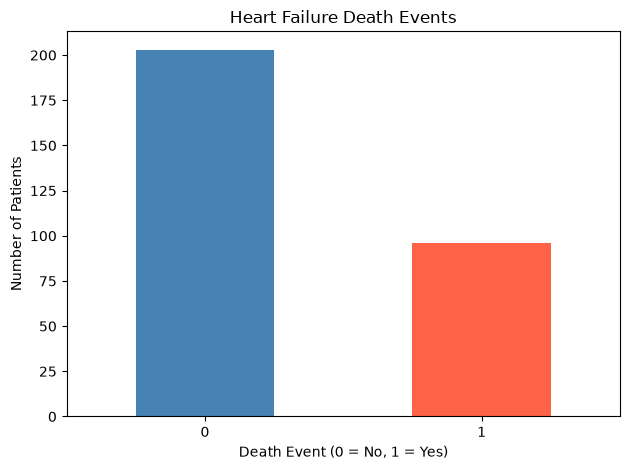

In [22]:
hf["DEATH_EVENT"].value_counts().sort_index().plot(
    kind="bar",
    color=["steelblue", "tomato"],
    title="Heart Failure Death Events",
    xlabel="Death Event (0 = No, 1 = Yes)",
    ylabel="Number of Patients",
    rot=0
)

plt.tight_layout()
plt.show()

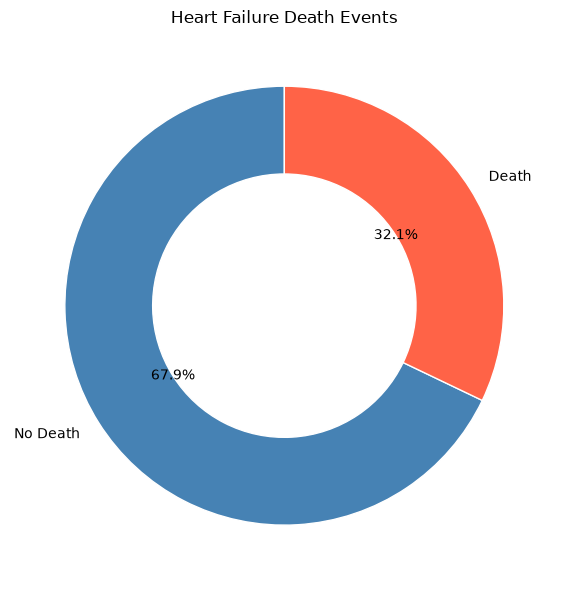

In [24]:
counts = hf["DEATH_EVENT"].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=["No Death", "Death"],
    autopct="%1.1f%%",
    colors=["steelblue", "tomato"],
    startangle=90,
    wedgeprops={"width": 0.4, "edgecolor": "white"}
)

plt.title("Heart Failure Death Events")
plt.tight_layout()
plt.show()

In [4]:
X = hf.drop(columns=["DEATH_EVENT"])
y = hf["DEATH_EVENT"]

X.head(), y.head()

(    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
 0  75.0        0                       582         0                 20   
 1  55.0        0                      7861         0                 38   
 2  65.0        0                       146         0                 20   
 3  50.0        1                       111         0                 20   
 4  65.0        1                       160         1                 20   
 
    high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
 0                    1  265000.00               1.9           130    1   
 1                    0  263358.03               1.1           136    1   
 2                    0  162000.00               1.3           129    1   
 3                    0  210000.00               1.9           137    1   
 4                    0  327000.00               2.7           116    0   
 
    smoking  time  
 0        0     4  
 1        0     6  
 2        1     7  
 3        

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((209, 12), (90, 12), (209,), (90,))

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
186,-0.947107,-0.930630,-0.017807,-0.895390,0.983081,-0.763763,-1.128230,-0.708512,-0.673385,-1.350676,-0.649437,0.572010
258,-1.381134,1.074541,-0.520265,1.116831,-1.078154,-0.763763,-0.315413,-0.526920,-0.431152,0.740370,-0.649437,1.322028
104,-0.079053,-0.930630,-0.532924,-0.895390,0.983081,1.309307,0.223078,0.835018,1.506714,-1.350676,-0.649437,-0.527153
161,-1.381134,1.074541,-0.457945,-0.895390,-0.253660,-0.763763,-0.914866,-0.526920,0.537781,0.740370,1.539795,-0.087488
263,0.615391,1.074541,-0.431654,1.116831,1.807575,-0.763763,-0.569418,-0.345329,0.780014,-1.350676,-0.649437,1.412547


In [7]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8333333333333334

Confusion Matrix:
 [[56  5]
 [10 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.88        61
           1       0.79      0.66      0.72        29

    accuracy                           0.83        90
   macro avg       0.82      0.79      0.80        90
weighted avg       0.83      0.83      0.83        90



In [8]:
import joblib

In [10]:
artifact = {
    "model": model,
    "scaler": scaler,
    "feature_names": X.columns.tolist()
}


joblib.dump(artifact, "heart_failure_artifacts.pkl")

print("Deployment artifact saved successfully as a PKL file.")

Deployment artifact saved successfully as a PKL file.


In [11]:
joblib.dump(scaler, "heart_failure_scaler.pkl")

artifact = {
    "model": model,
    "scaler": scaler,
    "feature_names": X.columns.tolist()
}

joblib.dump(artifact, "heart_failure_artifacts.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.
